In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from tslearn.metrics import dtw
import heapq

# --- 1. データロード ---
TARGET_feature = "close"
symbol = "1540.T"
#pca, train_features = joblib.load("pca_model.pkl")

symbol_df = pd.read_csv(f"{symbol}_data_with_features.csv", parse_dates=["ds"])
long_df = pd.read_csv("super_big_data_1.csv", parse_dates=["ds"])

# --- 4. 存在する学習列だけ抽出 ---
#existing_features = [col for col in train_features if col in df_renamed.columns]
#df_matched = df_renamed[existing_features]

# 特徴量カラム
feature_cols = [c for c in long_df.columns if c not in ["ds", "Ticker", TARGET_feature]]

# --- 2. TSLA直近20日特徴量 ---
X_tsla = symbol_df.sort_values("ds").iloc[-20:][feature_cols].values
X_tsla = (X_tsla - X_tsla.mean(axis=0)) / (X_tsla.std(axis=0) + 1e-8)

# --- 3. ビッグデータからサンプル生成（20日 + 未来20日） ---
samples = []
tickers = long_df["Ticker"].unique()

for ticker in tickers:
    df_t = long_df[long_df["Ticker"] == ticker].sort_values("ds")
    for i in range(len(df_t) - 40):
        past = df_t.iloc[i:i+20][feature_cols].values
        future_close = df_t.iloc[i+20:i+40][TARGET_feature].values

        if past.shape[0] == 20 and future_close.shape[0] == 20:
            # 特徴量を標準化
            past = (past - past.mean(axis=0)) / (past.std(axis=0) + 1e-8)

            # 未来20日の累積リターン系列
            future_return = future_close[1:] / future_close[:-1] - 1
            cum_return = np.cumprod(1 + future_return) - 1
            samples.append((ticker, df_t.iloc[i+19]["ds"], past, cum_return))

In [ ]:
# --- 4. 類似度計算（高速化版：二段階フィルタリング） ---
from scipy.spatial.distance import euclidean
import heapq

# ステージ1：高速なユークリッド距離で候補を絞り込む
print("--- ステージ1: 高速なユークリッド距離で候補を絞り込み中... ---")
euclidean_distances = []
# X_tslaを1次元配列に平坦化しておく（ループ内の計算を減らすため）
X_tsla_flat = X_tsla.flatten() 

for ticker, ds, past, future in samples:
    # 各サンプルの過去データも1次元に平坦化して距離を計算
    dist = euclidean(X_tsla_flat, past.flatten())
    # (ユークリッド距離, 元のデータ) の形で保存
    euclidean_distances.append((dist, ticker, ds, past, future))

# 絞り込む候補の数（全体の1-2%程度が目安ですが、PCスペックに応じて調整）
CANDIDATE_SIZE = 5000 
# ユークリッド距離が小さい上位CANDIDATE_SIZE件を候補として選ぶ
candidates = heapq.nsmallest(CANDIDATE_SIZE, euclidean_distances, key=lambda x: x[0])
print(f"--- ステージ1完了。{len(samples)}件から{len(candidates)}件の候補に絞り込みました ---")


# ステージ2：絞り込んだ候補にだけ、精密な多次元DTWを適用
print(f"\n--- ステージ2: {len(candidates)}件の候補に対して精密なDTW計算中... ---")
distances = []
# 候補リスト (candidates) の中身は (ユークリッド距離, ticker, ds, past, future)
# ユークリッド距離は不要なので _ で無視する
for _, ticker, ds, past, future in candidates:
    # ここで初めて、重いDTW計算を実行
    dist = multidim_dtw(X_tsla, past)
    distances.append((dist, ticker, ds, future))

print("--- ステージ2完了。全ての類似度計算が完了しました ---")

# この後の # --- 5. 上位Nシナリオを抽出 --- のコードは変更ありません

In [ ]:
# --- 4. 類似度計算（多次元DTW）遅いよ ---
def multidim_dtw(X, Y):
    """各次元でDTWを計算し平均"""
    dist_total = 0
    for d in range(X.shape[1]):
        x = X[:, d].ravel()
        y = Y[:, d].ravel()
        dist = dtw(x, y)
        dist_total += dist
    return dist_total / X.shape[1]

distances = []
for ticker, ds, past, future in samples:
    dist = multidim_dtw(X_tsla, past)
    distances.append((dist, ticker, ds, future))

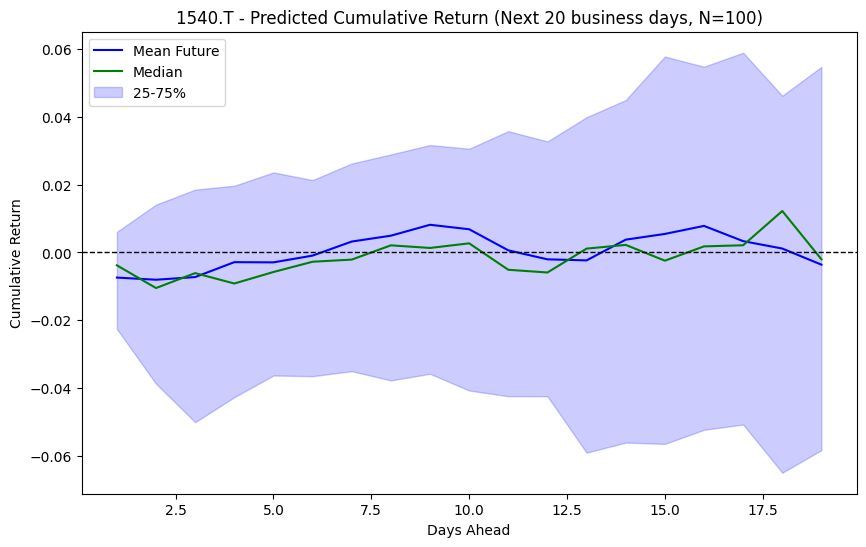

In [4]:
# --- 5. 上位Nシナリオを抽出 ---
N = 100
top_samples = heapq.nsmallest(N, distances, key=lambda x: x[0])

# --- 6. 未来20日の累積リターン系列を集計 ---
futures = np.array([s[3] for s in top_samples])  # (N, 19)
mean_future = futures.mean(axis=0)
p25 = np.percentile(futures, 25, axis=0)
p50 = np.percentile(futures, 50, axis=0)
p75 = np.percentile(futures, 75, axis=0)

# --- 7. 描画 ---
plt.figure(figsize=(10,6))
 
# 平均とパーセンタイル
plt.plot(range(1, len(mean_future)+1), mean_future, label="Mean Future", color="blue")
plt.plot(range(1, len(p50)+1), p50, label="Median", color="green")
plt.fill_between(range(1, len(p25)+1), p25, p75, color="blue", alpha=0.2, label="25-75%")

plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.legend()
plt.title(f"{symbol} - Predicted Cumulative Return (Next 20 business days, N={N})")
plt.xlabel("Days Ahead")
plt.ylabel("Cumulative Return")
plt.show()

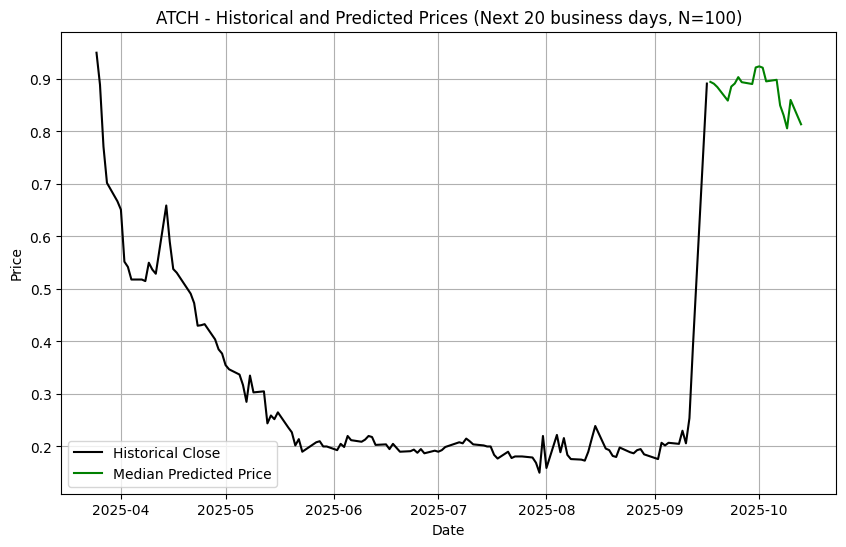

In [73]:
# --- 7. 描画（価格ベースに変換） ---
plt.figure(figsize=(10,6))

# TSLA直近終値
last_close = symbol_df.sort_values("ds").iloc[-1][TARGET_feature]

# 累積リターンを価格に変換
mean_price = last_close * (1 + mean_future)
p25_price = last_close * (1 + p25)
p50_price = last_close * (1 + p50)
p75_price = last_close * (1 + p75)

# 日付軸（未来20日）
future_days = pd.date_range(start=symbol_df["ds"].max() + pd.Timedelta(days=1), periods=19, freq='B')

# 過去20日分の終値
past_dates = symbol_df.sort_values("ds").iloc[-120:]["ds"]
past_prices = symbol_df.sort_values("ds").iloc[-120:][TARGET_feature]

# 過去終値をプロット
plt.plot(past_dates, past_prices, label="Historical Close", color="black")

# 未来予測
#plt.plot(future_days, mean_price, label="Mean Predicted Price", color="blue")
plt.plot(future_days, p50_price, label="Median Predicted Price", color="green")
#plt.fill_between(future_days, p25_price, p75_price, color="blue", alpha=0.2, label="25-75%")

plt.legend()
plt.title(f"{symbol} - Historical and Predicted Prices (Next 20 business days, N={N})")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

C:\Users\ds221k10134\AppData\Local\Temp\ipykernel_14468\3928396504.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  smoothed_mean_price = mean_price_series.rolling(window=smoothing_window, min_periods=1, center=True).mean().fillna(method='bfill').values
C:\Users\ds221k10134\AppData\Local\Temp\ipykernel_14468\3928396504.py:37: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  smoothed_p25_price = p25_price_series.rolling(window=smoothing_window, min_periods=1, center=True).mean().fillna(method='bfill').values
C:\Users\ds221k10134\AppData\Local\Temp\ipykernel_14468\3928396504.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  smoothed_p75_price = p75_price_series.rolling(window=smoothing_window, min_periods=1, center=True).

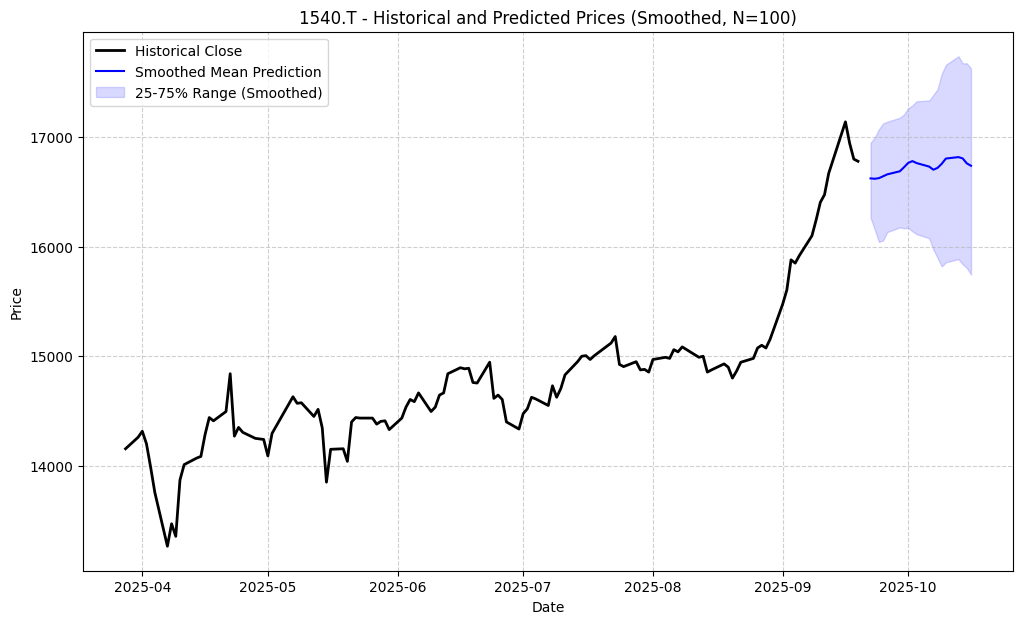

In [15]:
# --- 7. 描画（改善版：外れ値除外と平滑化） ---
import pandas as pd

# --- 7-1. 外れ値の除外（トリム平均）---
# 各将来日（19日分）ごとに、上位5%と下位5%の極端なシナリオを除外して平均を計算
trimmed_mean_future = []
for i in range(futures.shape[1]):  # futures は (N, 19) の配列
    day_data = futures[:, i]
    # 5パーセンタイルと95パーセンタイルの値を計算
    p5 = np.percentile(day_data, 5)
    p95 = np.percentile(day_data, 95)
    # 5%～95%の範囲内にあるデータのみを抽出
    trimmed_data = day_data[(day_data >= p5) & (day_data <= p95)]
    # 抽出したデータで平均値を計算
    trimmed_mean_future.append(trimmed_data.mean())

trimmed_mean_future = np.array(trimmed_mean_future)

# --- 7-2. 累積リターンを価格に変換 ---
# TSLAの直近終値を取得
last_close = symbol_df.sort_values("ds").iloc[-1][TARGET_feature]

# トリム平均とパーセンタイルを価格に変換
mean_price = last_close * (1 + trimmed_mean_future)
p25_price = last_close * (1 + p25) # p25, p75 は元のパーセンタイルを使用
p75_price = last_close * (1 + p75)

# --- 7-3. 予測線を滑らかにする（平滑化）---
# PandasのSeriesに変換して移動平均を計算
smoothing_window = 3 # 3日間の移動平均で滑らかにする
mean_price_series = pd.Series(mean_price)
p25_price_series = pd.Series(p25_price)
p75_price_series = pd.Series(p75_price)

# fillna(method='bfill') は、最初の数日間のNaNを未来の値で埋める処理
smoothed_mean_price = mean_price_series.rolling(window=smoothing_window, min_periods=1, center=True).mean().fillna(method='bfill').values
smoothed_p25_price = p25_price_series.rolling(window=smoothing_window, min_periods=1, center=True).mean().fillna(method='bfill').values
smoothed_p75_price = p75_price_series.rolling(window=smoothing_window, min_periods=1, center=True).mean().fillna(method='bfill').values


# --- 7-4. 描画 ---
plt.figure(figsize=(12, 7))

# 日付軸の準備
past_dates = symbol_df.sort_values("ds").iloc[-120:]["ds"]
past_prices = symbol_df.sort_values("ds").iloc[-120:][TARGET_feature]
future_days = pd.date_range(start=symbol_df["ds"].max() + pd.Timedelta(days=1), periods=19, freq='B')

# 過去の終値をプロット
plt.plot(past_dates, past_prices, label="Historical Close", color="black", linewidth=2)

# 平滑化した未来予測をプロット
plt.plot(future_days, smoothed_mean_price, label="Smoothed Mean Prediction", color="blue", linestyle='-')
plt.fill_between(future_days, smoothed_p25_price, smoothed_p75_price, color="blue", alpha=0.15, label="25-75% Range (Smoothed)")

# グラフの体裁を整える
plt.legend()
plt.title(f"{symbol} - Historical and Predicted Prices (Smoothed, N={N})")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

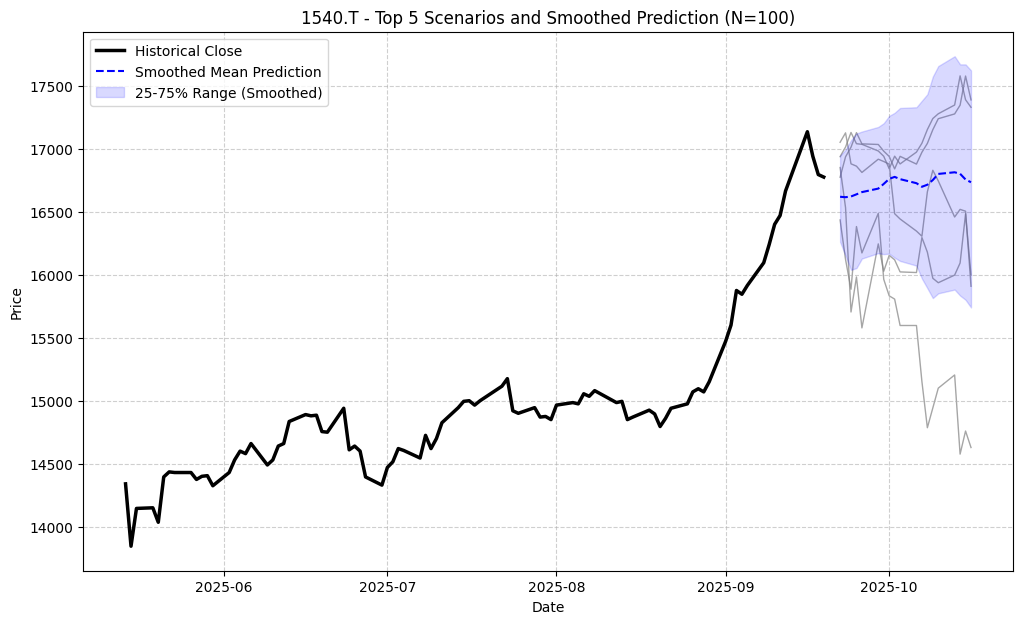

In [8]:
# --- 7-4. 描画（個別シナリオ追加版） ---
plt.figure(figsize=(12, 7))

# 日付軸の準備
past_dates = symbol_df.sort_values("ds").iloc[-90:]["ds"]
past_prices = symbol_df.sort_values("ds").iloc[-90:][TARGET_feature]
future_days = pd.date_range(start=symbol_df["ds"].max() + pd.Timedelta(days=1), periods=19, freq='B')

# 過去の終値をプロット
plt.plot(past_dates, past_prices, label="Historical Close", color="black", linewidth=2.5, zorder=3)


# --- 7-5. 上位シナリオの個別描画（ここからが追加部分）---
num_scenarios_to_plot = 5  # 描画する上位シナリオの数

# 上位のシナリオをループ処理で描画
for i in range(num_scenarios_to_plot):
    # top_samplesからi番目のシナリオの未来リターン系列を取得
    # top_samples は (dist, ticker, ds, future) というタプルのリスト
    individual_future_return = top_samples[i][3]
    
    # 累積リターンを価格に変換
    individual_price = last_close * (1 + individual_future_return)
    
    # 個別の予測を細く、半透明な線でプロット
    # ラベルは付けずに凡例をシンプルに保つ
    plt.plot(future_days, individual_price, color='gray', linewidth=1, alpha=0.7, zorder=1)

# --- ここまでが追加部分 ---


# 平滑化した未来予測の平均・範囲をプロット
plt.plot(future_days, smoothed_mean_price, label="Smoothed Mean Prediction", color="blue", linestyle='--', zorder=3)
plt.fill_between(future_days, smoothed_p25_price, smoothed_p75_price, color="blue", alpha=0.15, label="25-75% Range (Smoothed)", zorder=2)


# グラフの体裁を整える
plt.legend()
plt.title(f"{symbol} - Top {num_scenarios_to_plot} Scenarios and Smoothed Prediction (N={N})")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [9]:
# --- 上位シナリオの詳細情報を表示 ---
num_scenarios_to_show = 10 # 表示したいシナリオの数

print("--- 類似度上位シナリオの詳細 ---")
for i, sample_data in enumerate(top_samples[:num_scenarios_to_show]):
    # タプルから各データを取得
    distance = sample_data[0]
    ticker = sample_data[1]
    date = sample_data[2]
    
    # 見やすくフォーマットして表示
    # date.strftime('%Y-%m-%d') は日付を「年-月-日」の形式に変換します
    print(f"【{i+1}位】 Ticker: {ticker}, Date: {date.strftime('%Y-%m-%d')}, 類似度(距離): {distance:.4f}")

--- 類似度上位シナリオの詳細 ---
【1位】 Ticker: FXI, Date: 2024-10-29, 類似度(距離): 1.1953
【2位】 Ticker: 6690.HK, Date: 2024-10-10, 類似度(距離): 1.2126
【3位】 Ticker: SBIN.NS, Date: 2023-12-21, 類似度(距離): 1.2374
【4位】 Ticker: LMT, Date: 2024-08-23, 類似度(距離): 1.2375
【5位】 Ticker: LMT, Date: 2024-08-22, 類似度(距離): 1.2493
【6位】 Ticker: 0267.HK, Date: 2024-10-10, 類似度(距離): 1.2530
【7位】 Ticker: FXI, Date: 2024-10-30, 類似度(距離): 1.2595
【8位】 Ticker: 9618.HK, Date: 2024-10-10, 類似度(距離): 1.2622
【9位】 Ticker: MCHI, Date: 2024-10-30, 類似度(距離): 1.2680
【10位】 Ticker: MCHI, Date: 2024-10-29, 類似度(距離): 1.2707


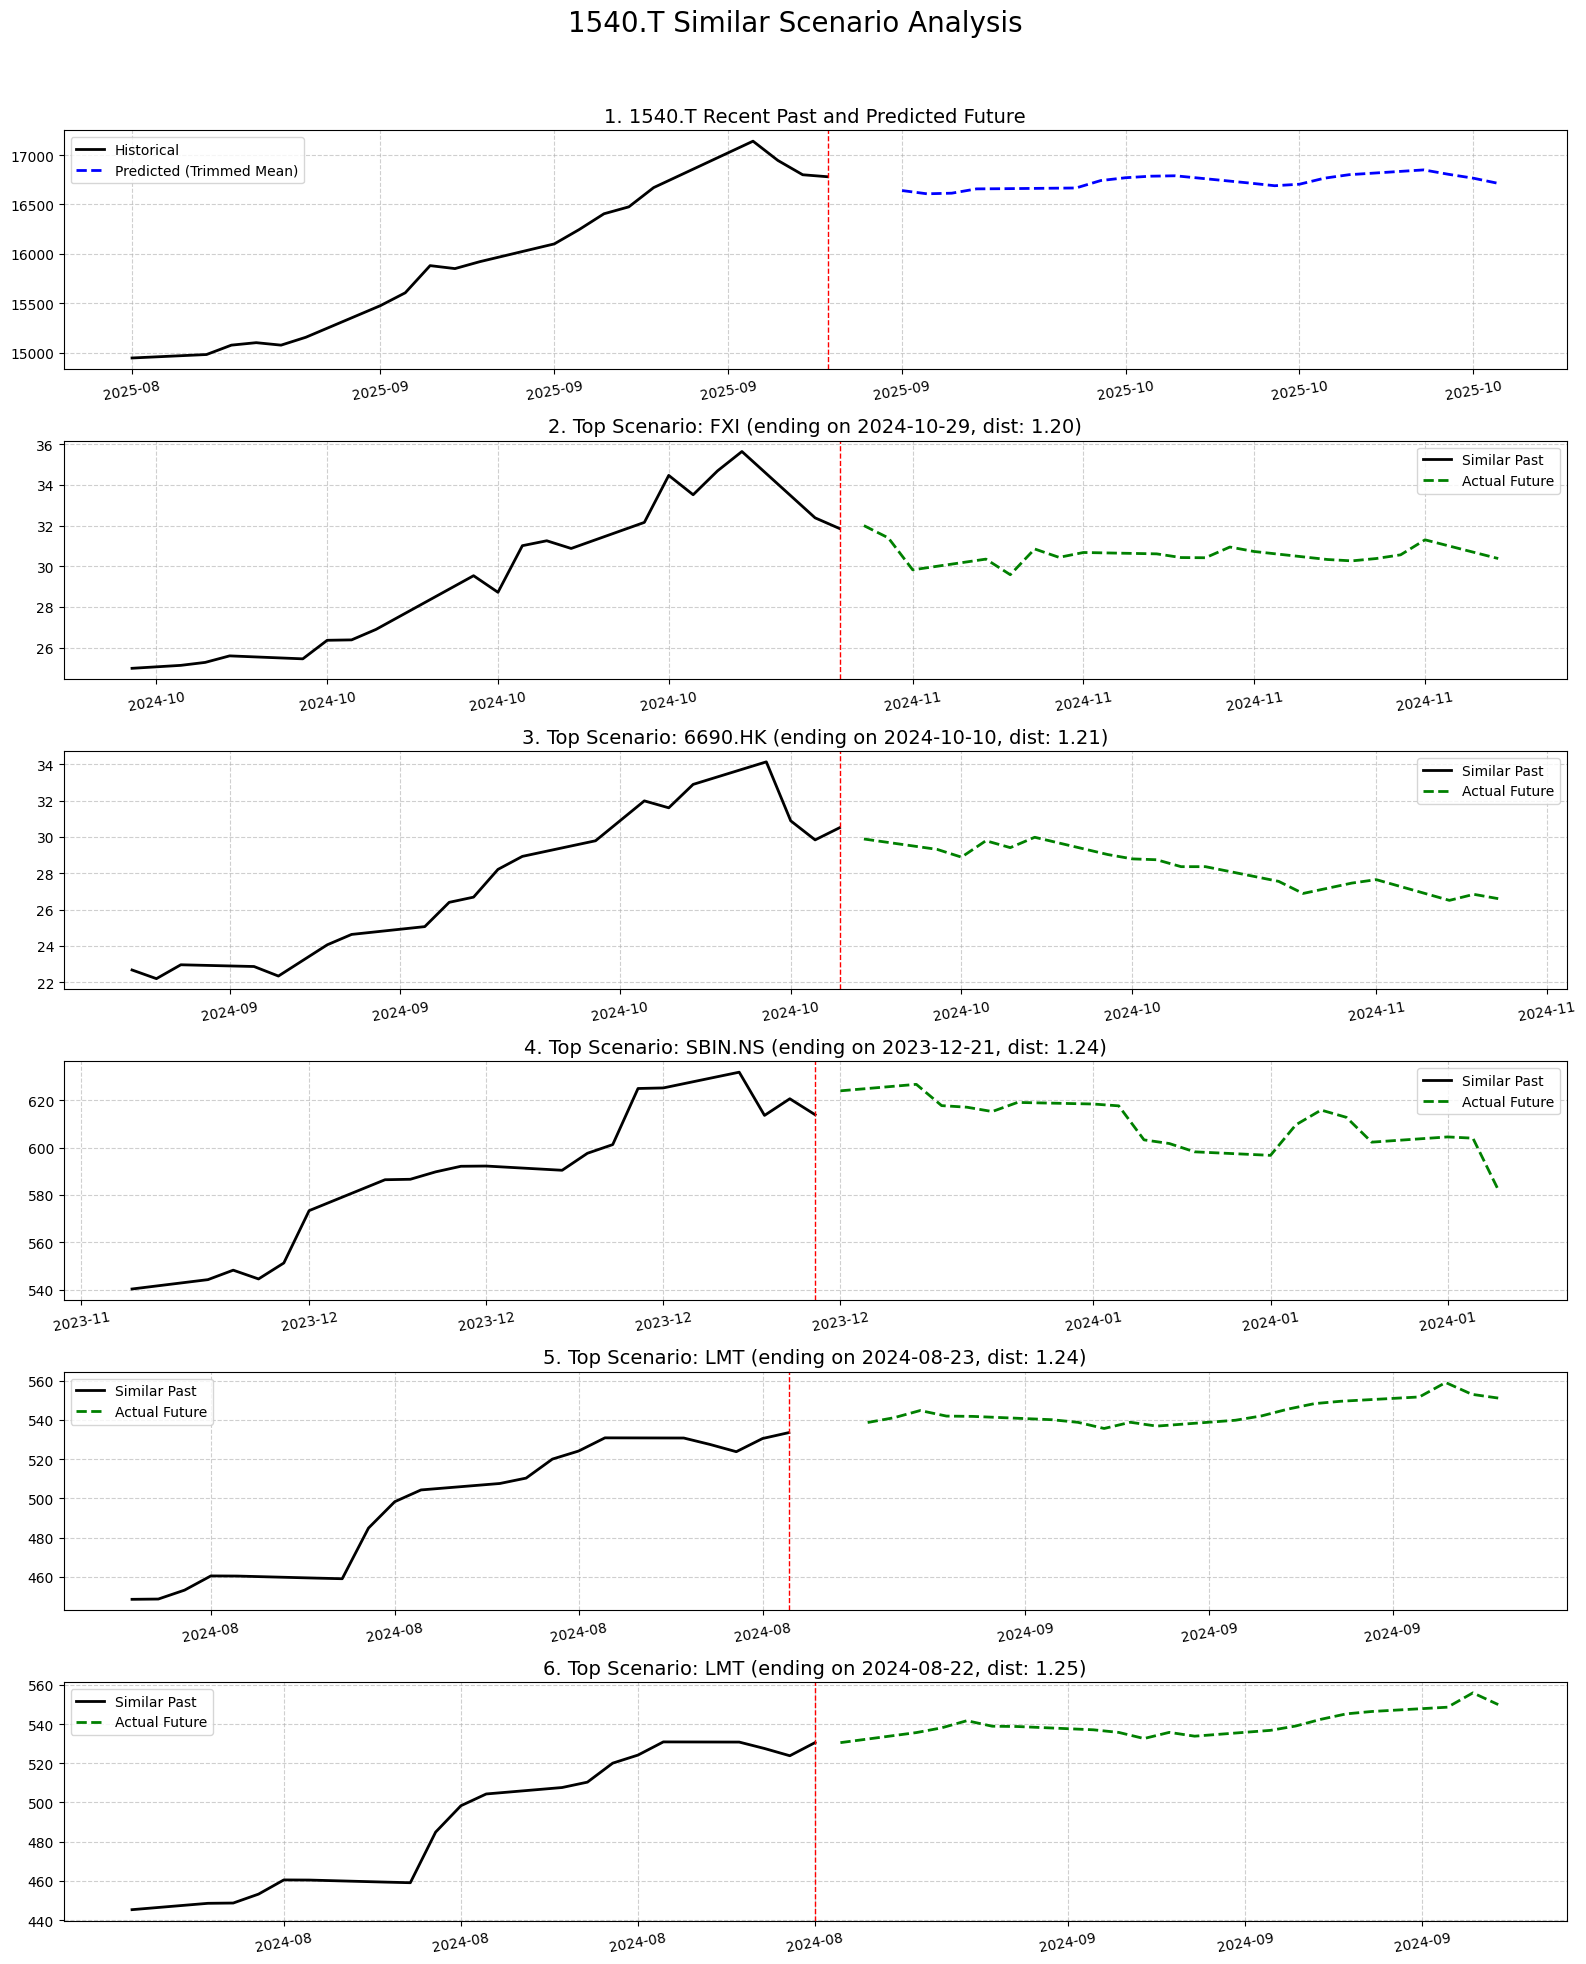

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- 準備：対象銘柄の未来予測（トリム平均）を計算 ---
futures = np.array([s[3] for s in top_samples])
trimmed_mean_future = []
for i in range(futures.shape[1]):
    day_data = futures[:, i]
    p5 = np.percentile(day_data, 5)
    p95 = np.percentile(day_data, 95)
    trimmed_data = day_data[(day_data >= p5) & (day_data <= p95)]
    trimmed_mean_future.append(trimmed_data.mean())
trimmed_mean_future = np.array(trimmed_mean_future)

# --- 描画設定 ---
fig, axes = plt.subplots(6, 1, figsize=(16, 20), sharex=False)
fig.suptitle(f'{symbol} Similar Scenario Analysis', fontsize=20)

# --- プロット1：TSLAの現在と未来予測 ---
ax = axes[0]
# 過去20日間のデータを取得
tsla_past = symbol_df.sort_values("ds").iloc[-20:]
past_dates = tsla_past["ds"]
past_prices = tsla_past[TARGET_feature]

# 未来予測を価格に変換
last_close = past_prices.iloc[-1]
future_prices = last_close * (1 + trimmed_mean_future)
future_dates = pd.date_range(start=past_dates.iloc[-1] + pd.Timedelta(days=1), periods=19, freq='B')

# 過去と未来をプロット
ax.plot(past_dates, past_prices, color='black', linewidth=2, label='Historical')
ax.plot(future_dates, future_prices, color='blue', linestyle='--', linewidth=2, label='Predicted (Trimmed Mean)')
# ★★★ パーセンタイル範囲を描画 ★★★
#ax.fill_between(future_dates, p25, p75, color='blue', alpha=0.2, label='25-75% Range')

# 過去と未来の境界線
boundary_date = past_dates.iloc[-1]
ax.axvline(x=boundary_date, color='r', linestyle='--', linewidth=1)
ax.set_title(f"1. {symbol} Recent Past and Predicted Future", fontsize=14)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# --- プロット2-6：類似シナリオ上位5件 ---
for i, sample in enumerate(top_samples[:5]):
    ax = axes[i + 1]
    
    distance, ticker, end_date, future_cum_return = sample
    
    # シナリオの過去20日間のデータをlong_dfから取得
    df_ticker = long_df[long_df['Ticker'] == ticker].sort_values('ds').set_index('ds')
    scenario_past = df_ticker.loc[:end_date].iloc[-20:]
    
    # シナリオの未来（実績）を価格に変換
    scenario_last_close = scenario_past[TARGET_feature].iloc[-1]
    scenario_future_prices = scenario_last_close * (1 + future_cum_return)
    scenario_future_dates = pd.date_range(start=scenario_past.index[-1] + pd.Timedelta(days=1), periods=19, freq='B')
    
    # 過去と未来（実績）をプロット
    ax.plot(scenario_past.index, scenario_past[TARGET_feature], color='black', linewidth=2, label='Similar Past')
    ax.plot(scenario_future_dates, scenario_future_prices, color='green', linestyle='--', linewidth=2, label='Actual Future')
    
    # 境界線
    ax.axvline(x=scenario_past.index[-1], color='r', linestyle='--', linewidth=1)
    title_date = end_date.strftime('%Y-%m-%d')
    ax.set_title(f"{i+2}. Top Scenario: {ticker} (ending on {title_date}, dist: {distance:.2f})", fontsize=14)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

# 全てのプロットの日付フォーマットを統一
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # suptitleとの重なりを調整
plt.show()

In [78]:
num_tickers = long_df['Ticker'].nunique()
print(f"ティッカーシンボルの種類: {num_tickers} 件")

ティッカーシンボルの種類: 320 件


In [20]:
#LGPHの全学習
import pandas as pd
import numpy as np
import lightgbm as lgb
import joblib
from prophet import Prophet
import matplotlib.pyplot as plt
from tslearn.metrics import dtw
import heapq
# (top_samples, lgph_gatekeeper, base_f, trend_f, range_f, all_training_features, long_df が定義済みと仮定)
df = symbol_df.copy()
def train_lgph_model(df, target_variable="close"):
    """
    与えられたデータフレームでLGPHモデル（門番、大きさ、方向）を学習し、
    学習済みモデルを返す関数。
    """
    print(f"\n--- LGPHモデルを学習開始 (対象: {target_variable}) ---")
    
    # 準備1: Prophetによるベースラインと外れ値の定義
    prophet_df = pd.DataFrame({'ds': df['ds'], 'y': df[target_variable]})
    model_prophet = Prophet(interval_width=0.95)
    model_prophet.fit(prophet_df)
    forecast = model_prophet.predict(prophet_df[['ds']])
    df = pd.merge(df, forecast[['ds', 'yhat', 'yhat_upper', 'yhat_lower']], on='ds', how='inner')
    
    conditions = [df[target_variable] > df['yhat_upper'], df[target_variable] < df['yhat_lower']]
    choices = [df[target_variable] - df['yhat_upper'], df[target_variable] - df['yhat_lower']]
    df['outlier_error'] = np.select(conditions, choices, default=0.0)
    
    # 準備2: 3つの目的変数の作成
    df['is_outlier'] = (df['outlier_error'] != 0).astype(int)
    df['error_sign'] = np.sign(df['outlier_error']).astype(int)

    # 準備3: レジームフィルターの適用
    # ★★★ カラム名を 'Adx_14' -> 'ADX_14', 'Sma_75' -> 'EMA_75' に修正 ★★★
    conditions_regime = [
        (df['ADX_14'] >= 25) & (df[target_variable] > df['EMA_75']),
        (df['ADX_14'] >= 25) & (df[target_variable] < df['EMA_75']),
    ]
    choices_regime = ['上昇トレンド', '下降トレンド']
    df['Market_Regime'] = np.select(conditions_regime, choices_regime, default='レンジ相場')
    
    # 特徴量リスト (こちらも新しい名前に修正)
    # ★★★ カラム名を rename_dict に合わせて修正 ★★★
    base_features = ['終値前日比', 'Volume_Shape', 'RSI_14', 'Rolling_Std_5D']
    trend_features = ['ADX_14', 'MACD_12_26_9', 'EMA_5', 'EMA_25', 'PSARl_0.02_0.2', 'PSARs_0.02_0.2']
    range_features = ['STOCHk_14_3_3', 'BBP_20_2.0', 'BB_Width']
    
    # レジームごとに学習データを構築
    X_final = pd.DataFrame()
    y_class_final = pd.Series(dtype=int)

    for regime in ['上昇トレンド', '下降トレンド', 'レンジ相場']:
        regime_df = df[df['Market_Regime'] == regime].copy()
        if regime in ['上昇トレンド', '下降トレンド']:
            selected_features = base_features + trend_features
        else:
            selected_features = base_features + range_features
        
        # 存在しないカラムを除外する処理を追加して安全性を高める
        existing_features = [f for f in selected_features if f in regime_df.columns]
        X_regime = regime_df[existing_features]
        
        X_final = pd.concat([X_final, X_regime])
        y_class_final = pd.concat([y_class_final, regime_df['is_outlier']])

    X_final.fillna(0, inplace=True)
    X_final = X_final.sort_index()
    y_class_final = y_class_final.sort_index()

    # 学習1: 門番モデル (外れ値分類)
    lgbm_clf = None
    if not y_class_final.empty and y_class_final.nunique() >= 2:
        # クラス0または1のサンプル数が0の場合のエラーを回避
        value_counts = y_class_final.value_counts()
        if value_counts.get(0, 0) > 0 and value_counts.get(1, 0) > 0:
            scale_pos_weight = value_counts[0] / value_counts[1]
            lgbm_clf = lgb.LGBMClassifier(objective='binary', scale_pos_weight=scale_pos_weight, random_state=42)
            lgbm_clf.fit(X_final, y_class_final)
            print("LGPH: 門番モデルの学習完了。")
        else:
            print("LGPH: 門番モデルの学習をスキップ（データが1クラスのみ）。")
    
    return lgbm_clf, base_features, trend_features, range_features

lgph_gatekeeper, base_f, trend_f, range_f = train_lgph_model(symbol_df, target_variable="close")

print("\n--- 100個の全シナリオに対する信憑性スコアを計算中 ---")

all_scenario_scores = []
all_training_features = sorted(list(set(base_f + trend_f + range_f)))

for i, sample in enumerate(top_samples):
    dist, ticker, end_date, future_cum_return = sample
    
    # シナリオの過去20日間のデータを取得・準備
    df_ticker = long_df[long_df['Ticker'] == ticker].sort_values('ds').reset_index(drop=True)
    
    if end_date not in df_ticker['ds'].values: continue
    end_date_iloc = df_ticker[df_ticker['ds'] == end_date].index[0]
    if end_date_iloc < 19: continue

    scenario_past_df = df_ticker.iloc[end_date_iloc - 19 : end_date_iloc + 1].copy()
    if scenario_past_df.empty: continue

    # レジームを定義
    conditions_regime = [
        (scenario_past_df['ADX_14'] >= 25) & (scenario_past_df['close'] > scenario_past_df['EMA_75']),
        (scenario_past_df['ADX_14'] >= 25) & (scenario_past_df['close'] < scenario_past_df['EMA_75']),
    ]
    choices_regime = ['上昇トレンド', '下降トレンド']
    scenario_past_df['Market_Regime'] = np.select(conditions_regime, choices_regime, default='レンジ相場')

    # 予測用の特徴量を選択・整形
    last_day_regime = scenario_past_df['Market_Regime'].iloc[-1]
    if last_day_regime in ['上昇トレンド', '下降トレンド']:
        selected_features = base_f + trend_f
    else:
        selected_features = base_f + range_f
    
    X_scenario_partial = scenario_past_df[selected_features].fillna(0)
    X_scenario = pd.DataFrame(0, index=X_scenario_partial.index, columns=all_training_features)
    X_scenario.update(X_scenario_partial)

    # 門番モデルで「外れ値でない確率」を予測
    non_outlier_probabilities = lgph_gatekeeper.predict_proba(X_scenario)[:, 0]
    
    # このシナリオの信憑性スコア
    credibility_score = np.mean(non_outlier_probabilities)
    all_scenario_scores.append(credibility_score)

# ★★★ 100個のスコアの平均値を計算 ★★★
if all_scenario_scores:
    average_credibility_score = np.mean(all_scenario_scores)
    print("\n--- 分析完了 ---")
    print(f"トリム平均線の信憑性スコア (100シナリオの平均): {average_credibility_score:.4f}")
else:
    print("\n--- 分析完了 ---")
    print("スコアリング可能なシナリオがありませんでした。")

C:\Users\ds221k10134\Downloads\Gemini_tyato\Gemini\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- LGPHモデルを学習開始 (対象: close) ---


18:40:14 - cmdstanpy - INFO - Chain [1] start processing
18:40:14 - cmdstanpy - INFO - Chain [1] done processing


[LightGBM] [Info] Number of positive: 38, number of negative: 628
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001682 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1702
[LightGBM] [Info] Number of data points in the train set: 666, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.057057 -> initscore=-2.804954
[LightGBM] [Info] Start training from score -2.804954
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

C:\Users\ds221k10134\AppData\Local\Temp\ipykernel_14468\986887094.py:122: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[10.29599657  9.89560987  9.25871288  9.68046833  9.67870704 10.9985275
 12.52824827 14.63586427 18.39332515 21.88239597 25.82023703 29.55663813
 33.10808836 36.47480598 39.98915489 42.70772613 45.38743223 48.11702301
 46.83419842 45.57358141]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_scenario.update(X_scenario_partial)
C:\Users\ds221k10134\AppData\Local\Temp\ipykernel_14468\986887094.py:122: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[25.15259925 25.15041534 25.15960936 25.19275874 25.21214795 25.30029583
 25.38315773 25.49925511 25.80969936 26.03348642 26.41643221 26.78860414
 27.10300127 27.49186324 28.02868065 28.45096456 28.93119397 29.4477222
 29.67341005 29.84138074]'


--- 分析完了 ---
トリム平均線の信憑性スコア (100シナリオの平均): 0.9081


C:\Users\ds221k10134\AppData\Local\Temp\ipykernel_14468\986887094.py:122: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[12.90842315 12.9693349  13.16326037 13.59287095 14.23839998 15.37350802
 16.33604005 16.38772529 17.21023074 20.30247742 23.52728638 26.74024679
 29.74729019 31.28876812 32.94181504 34.47678718 36.05795722 35.9518651
 35.85335099 34.91414142]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_scenario.update(X_scenario_partial)
C:\Users\ds221k10134\AppData\Local\Temp\ipykernel_14468\986887094.py:122: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[266.77257653 267.04239703 267.17188953 267.43341232 267.77197185
 268.21900748 268.38503617 268.6354473  269.09079694 270.50507017
 272.25147816 274.19984609 275.81898071 277.27620126 278.6362745
 280.04866688 281.44956523 282.42135208 283.213

信憑性スコアが90.0%以上のエリートシナリオ数: 86件

--- 分析完了 ---
高信憑性シナリオ群による平均線自体の信憑性スコア: 0.9997


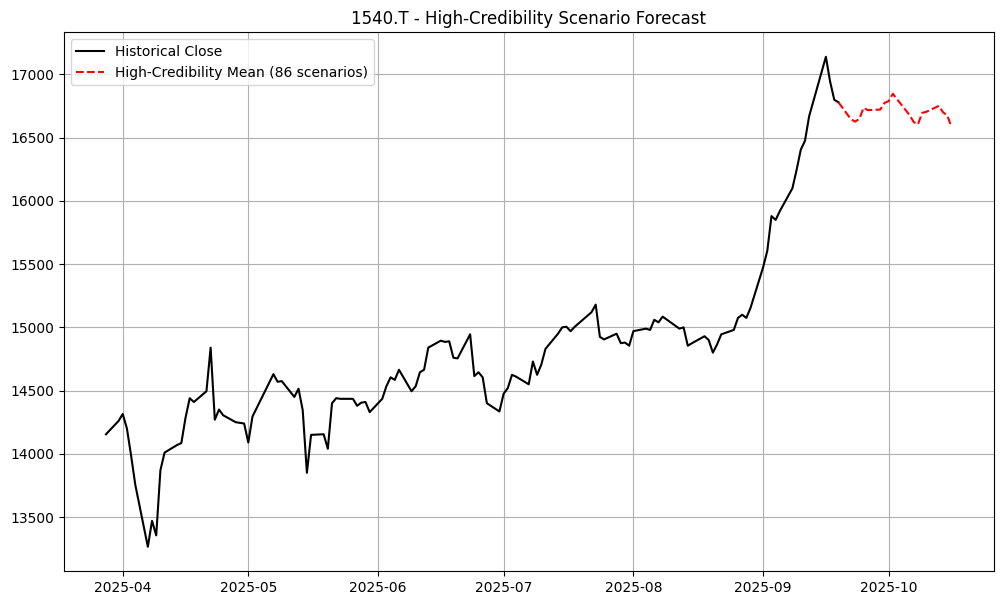

In [38]:
# (これまでの計算で、100個のシナリオそれぞれの個別スコアを計算した
# all_scenario_scores リストが作成済みであると仮定)

# --- 1. 信憑性スコアが90%以上の「エリートシナリオ」を選別 ---
CREDIBILITY_THRESHOLD = 0.90
high_credibility_indices = [i for i, score in enumerate(all_scenario_scores) if score >= CREDIBILITY_THRESHOLD]

print(f"信憑性スコアが{CREDIBILITY_THRESHOLD*100}%以上のエリートシナリオ数: {len(high_credibility_indices)}件")

if len(high_credibility_indices) > 0:
    # --- 2. エリートシナリオだけで新しい平均線を作成 ---
    high_cred_futures = futures[high_credibility_indices]
    high_cred_mean_future = np.mean(high_cred_futures, axis=0)

    # --- 3. エリートシナリオ群から「平均的な過去」を合成 ---
    synthetic_past_features_list_elite = []
    for idx in high_credibility_indices:
        # (以前のコードと同様に、シナリオの過去特徴量を取得)
        _, ticker, end_date, _ = top_samples[idx]
        df_ticker = long_df[long_df['Ticker'] == ticker].sort_values('ds').reset_index(drop=True)
        if end_date not in df_ticker['ds'].values: continue
        end_date_iloc = df_ticker[df_ticker['ds'] == end_date].index[0]
        if end_date_iloc < 19: continue
        scenario_past_df = df_ticker.iloc[end_date_iloc - 19 : end_date_iloc + 1].copy()
        if scenario_past_df.empty: continue
        
        scenario_features = scenario_past_df.reindex(columns=all_training_features).fillna(0)
        synthetic_past_features_list_elite.append(scenario_features.values)
    
    if synthetic_past_features_list_elite:
        # エリートシナリオの過去特徴量を平均化
        average_past_features_elite = np.mean(np.array(synthetic_past_features_list_elite), axis=0)
        average_past_df_elite = pd.DataFrame(average_past_features_elite, columns=all_training_features)

        # --- 4. 新しい平均線の信憑性スコアを検証 ---
        non_outlier_probabilities_elite = lgph_gatekeeper.predict_proba(average_past_df_elite)[:, 0]
        final_credibility_score = np.mean(non_outlier_probabilities_elite)
        
        print("\n--- 分析完了 ---")
        print(f"高信憑性シナリオ群による平均線自体の信憑性スコア: {final_credibility_score:.4f}")

        # --- 5. 描画 ---
        # (描画コードで、smoothed_mean_price の代わりに high_cred_mean_future から生成した価格を使う)
        plt.figure(figsize=(12, 7))
        last_close = symbol_df.sort_values("ds").iloc[-1][TARGET_feature]
        
        # 過去データをプロット
        past_dates_display = symbol_df.sort_values("ds").iloc[-120:]["ds"]
        past_prices_display = symbol_df.sort_values("ds").iloc[-120:][TARGET_feature]
        plt.plot(past_dates_display, past_prices_display, label="Historical Close", color="black")

        # 新しい平均線を価格に変換してプロット
        future_prices_elite = last_close * (1 + np.insert(high_cred_mean_future, 0, 0))
        future_dates = pd.date_range(start=symbol_df["ds"].max(), periods=20, freq='B')
        plt.plot(future_dates, future_prices_elite, label=f"High-Credibility Mean ({len(high_credibility_indices)} scenarios)", color='red', linestyle='--')
        
        plt.title(f"{symbol} - High-Credibility Scenario Forecast")
        plt.legend()
        plt.grid(True)
        plt.show()

    else:
        print("エラー: 平均的な過去を合成できるエリートシナリオがありませんでした。")
else:
    print(f"信憑性スコアが{CREDIBILITY_THRESHOLD*100}%以上のシナリオは見つかりませんでした。")